Purpose: detect anomalies/events in the preprocessed UCI Air Quality dataset using a residual-MAD detector and Isolation Forest, then summarize/visualize flagged points.

Load libraries and set plotting/output defaults.

In [8]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

SEED = 42
SAVE_FIGS = True  # set False to skip writing figures
FIG_DIR = Path('figures')
OUT_DIR = Path('artifacts')
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 120})
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

Load preprocessed data (output of the preprocessing notebook).

In [9]:
data_path = Path('preprocessed_air_quality.csv')
if not data_path.exists():
    raise FileNotFoundError('Run the preprocessing notebook first to create preprocessed_air_quality.csv')

df = pd.read_csv(data_path, parse_dates=['datetime'])
df = df.sort_values('datetime').set_index('datetime')
df = df[~df.index.duplicated(keep='first')]

GT_STREAMS = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
SENSOR_STREAMS = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
ALL_STREAMS = GT_STREAMS + SENSOR_STREAMS

TRAIN_END = pd.Timestamp('2005-01-01')
train_rows = int((df.index < TRAIN_END).sum())

context = pd.DataFrame(index=df.index)
context['is_weekend'] = df.index.dayofweek >= 5
context['dayofweek'] = df.index.dayofweek
context['hour'] = df.index.hour
context['weekday'] = df.index.dayofweek
context['month'] = df.index.month

if 'T' in df.columns:
    temp_series = pd.to_numeric(df['T'], errors='coerce')
    temp_quantiles = temp_series.quantile([0.2, 0.8])
    context['temperature'] = temp_series
    context['temp_bucket'] = pd.cut(
        temp_series,
        bins=[-np.inf, temp_quantiles.iloc[0], temp_quantiles.iloc[1], np.inf],
        labels=['low', 'mid', 'high'],
    )
else:
    context['temperature'] = np.nan
    context['temp_bucket'] = 'unknown'

context_lookup = context.reset_index()
context_lookup.columns = ['timestamp'] + list(context.columns)

print(f"Loaded {len(df):,} rows; training window ends at {TRAIN_END.date()} ({train_rows:,} rows)")
print(df[ALL_STREAMS].describe().T)


Loaded 9,357 rows; training window ends at 2005-01-01 (7,110 rows)
                count          mean       std       min       25%       50%  \
CO(GT)         9357.0 -1.245367e-16  1.000053 -1.406172 -0.772273 -0.213551   
NMHC(GT)       9357.0 -1.822489e-17  1.000053 -1.260741 -0.751597 -0.346986   
C6H6(GT)       9357.0 -1.457991e-16  1.000053 -1.169105 -0.701280 -0.285435   
NOx(GT)        9357.0  4.859970e-17  1.000053 -1.159300 -0.653650 -0.354188   
NO2(GT)        9357.0  1.336492e-16  1.000053 -2.349373 -0.710012 -0.140679   
PT08.S1(CO)    9357.0  4.282848e-16  1.000053 -2.019040 -0.761874 -0.188880   
PT08.S2(NMHC)  9357.0 -8.504947e-17  1.000053 -1.863912 -0.731635 -0.165496   
PT08.S3(NOx)   9357.0  1.822489e-17  1.000053 -1.956568 -0.731373 -0.120721   
PT08.S4(NO2)   9357.0  1.093493e-16  1.000053 -2.380021 -0.643680 -0.048148   
PT08.S5(O3)    9357.0 -1.275742e-16  1.000053 -1.987641 -0.742952 -0.167193   

                    75%       max  
CO(GT)         0.485280  6.

Define detectors and helper utilities.

In [10]:
import numpy.typing as npt

def robust_rolling_median(series: pd.Series, window: int = 24) -> pd.Series:
    filled = series.interpolate(limit_direction='both')
    return filled.rolling(window=window, min_periods=window // 2, center=True).median()

def mad_zscore(values: npt.ArrayLike) -> np.ndarray:
    arr = np.array(values, dtype=float)
    median = np.nanmedian(arr)
    mad = np.nanmedian(np.abs(arr - median))
    if not np.isfinite(mad) or mad == 0:
        mad = np.nanstd(arr)
    if not np.isfinite(mad) or mad == 0:
        return np.zeros_like(arr)
    return 0.6745 * (arr - median) / mad

def run_residual_detector(series: pd.Series, train_end: pd.Timestamp, window: int = 24, quantile: float = 0.99) -> pd.DataFrame:
    baseline = robust_rolling_median(series, window=window)
    residuals = series - baseline
    zscores = pd.Series(mad_zscore(residuals), index=series.index)
    train_scores = zscores.loc[zscores.index < train_end].abs().dropna().to_numpy()
    train_scores = train_scores[np.isfinite(train_scores)]
    if train_scores.size == 0:
        threshold = float(np.nanmax(np.abs(zscores.values)))
        if not np.isfinite(threshold) or threshold <= 0:
            threshold = 3.5
    else:
        threshold = float(np.nanquantile(train_scores, quantile))
    if not np.isfinite(threshold) or threshold <= 0:
        threshold = 3.5
    is_anom = zscores.abs() >= threshold
    return pd.DataFrame(
        {
            'timestamp': series.index,
            'stream': series.name,
            'method': 'residual_mad',
            'value': series.values,
            'baseline': baseline.values,
            'residual': residuals.values,
            'score': zscores.abs().values,
            'direction': np.sign(zscores.values),
            'threshold': threshold,
            'is_anomaly': is_anom.values,
        }
    )

def build_iso_features(series: pd.Series) -> pd.DataFrame:
    feats = pd.DataFrame(index=series.index)
    feats['value'] = series
    feats['diff_1h'] = series.diff()
    feats['diff_6h'] = series.diff(6)
    feats['diff_24h'] = series.diff(24)
    feats['roll_mean_6h'] = series.rolling(6, min_periods=1).mean()
    feats['roll_std_12h'] = series.rolling(12, min_periods=1).std()
    return feats

def run_isolation_forest(series: pd.Series, train_end: pd.Timestamp, contamination: float = 0.02) -> pd.DataFrame:
    feats = build_iso_features(series).replace([np.inf, -np.inf], np.nan)
    feats = feats.interpolate(limit_direction='both').ffill().bfill()
    scaler = StandardScaler()
    feat_scaled = pd.DataFrame(
        scaler.fit_transform(feats),
        index=feats.index,
        columns=feats.columns,
    )
    train_feat = feat_scaled.loc[feat_scaled.index < train_end]
    iso = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=SEED,
        bootstrap=True,
    )
    iso.fit(train_feat)
    scores = -iso.decision_function(feat_scaled)
    train_scores = scores[feat_scaled.index < train_end]
    train_scores = train_scores[np.isfinite(train_scores)]
    if train_scores.size == 0:
        threshold = float(np.nanmax(scores))
        if not np.isfinite(threshold):
            threshold = 0.0
    else:
        threshold = float(np.nanquantile(train_scores, 0.99))
    if not np.isfinite(threshold):
        threshold = 0.0
    return pd.DataFrame(
        {
            'timestamp': series.index,
            'stream': series.name,
            'method': 'isolation_forest',
            'value': series.values,
            'score': scores,
            'threshold': threshold,
            'is_anomaly': scores >= threshold,
        }
    )

def normalize_series(series: pd.Series):
    arr = pd.Series(series, dtype=float)
    valid = arr[np.isfinite(arr)]
    if valid.empty:
        return pd.Series(np.zeros(len(arr)), index=series.index, dtype=float), np.nan, np.nan
    min_val = float(valid.min())
    max_val = float(valid.max())
    span = max_val - min_val
    if span <= 0 or not np.isfinite(span):
        return pd.Series(np.zeros(len(arr)), index=series.index, dtype=float), min_val, max_val
    normalized = (arr - min_val) / span
    return normalized, min_val, max_val

def safe_stream_name(name: str) -> str:
    keep = ''.join(ch if ch.isalnum() else '_' for ch in name)
    while '__' in keep:
        keep = keep.replace('__', '_')
    return keep.strip('_').lower()


Run detectors for each stream and assemble summaries.

In [11]:
residual_scores = []
iso_scores = []

for stream in ALL_STREAMS:
    series = pd.to_numeric(df[stream], errors='coerce')
    residual_scores.append(run_residual_detector(series, TRAIN_END))
    iso_scores.append(run_isolation_forest(series, TRAIN_END))

residual_scores = pd.concat(residual_scores, ignore_index=True)
iso_scores = pd.concat(iso_scores, ignore_index=True)

def enrich_with_context(events: pd.DataFrame) -> pd.DataFrame:
    return events.merge(context_lookup, on='timestamp', how='left')

residual_anoms = enrich_with_context(residual_scores[residual_scores['is_anomaly']].copy())
iso_anoms = enrich_with_context(iso_scores[iso_scores['is_anomaly']].copy())

residual_anoms['detector'] = 'Residual (MAD)'
iso_anoms['detector'] = 'Isolation Forest'

stream_summary = (
    pd.concat(
        [
            residual_scores.assign(detector='Residual (MAD)'),
            iso_scores.assign(detector='Isolation Forest'),
        ],
        ignore_index=True,
    )
    .groupby(['detector', 'stream'], as_index=False)
    .agg(
        points=('timestamp', 'count'),
        anomalies=('is_anomaly', 'sum'),
        threshold=('threshold', 'max'),
        median_score=('score', 'median'),
    )
    .sort_values(['detector', 'stream'])
)

print('Detector summary preview:')
print(stream_summary)


Detector summary preview:
            detector         stream  points  anomalies  threshold  \
0   Isolation Forest       C6H6(GT)    9357        106   0.025063   
1   Isolation Forest         CO(GT)    9357         78   0.034858   
2   Isolation Forest       NMHC(GT)    9357         72   0.022143   
3   Isolation Forest        NO2(GT)    9357        271   0.028923   
4   Isolation Forest        NOx(GT)    9357         97   0.031915   
5   Isolation Forest    PT08.S1(CO)    9357         92   0.019703   
6   Isolation Forest  PT08.S2(NMHC)    9357        122   0.026444   
7   Isolation Forest   PT08.S3(NOx)    9357         74   0.045875   
8   Isolation Forest   PT08.S4(NO2)    9357        125   0.029223   
9   Isolation Forest    PT08.S5(O3)    9357         87   0.020117   
10    Residual (MAD)       C6H6(GT)    9357         90   5.415361   
11    Residual (MAD)         CO(GT)    9357         93   4.384250   
12    Residual (MAD)       NMHC(GT)    9357         73   5.545392   
13    Re

Context profiles for anomalies (weekday/weekend, hour, temperature, etc.).

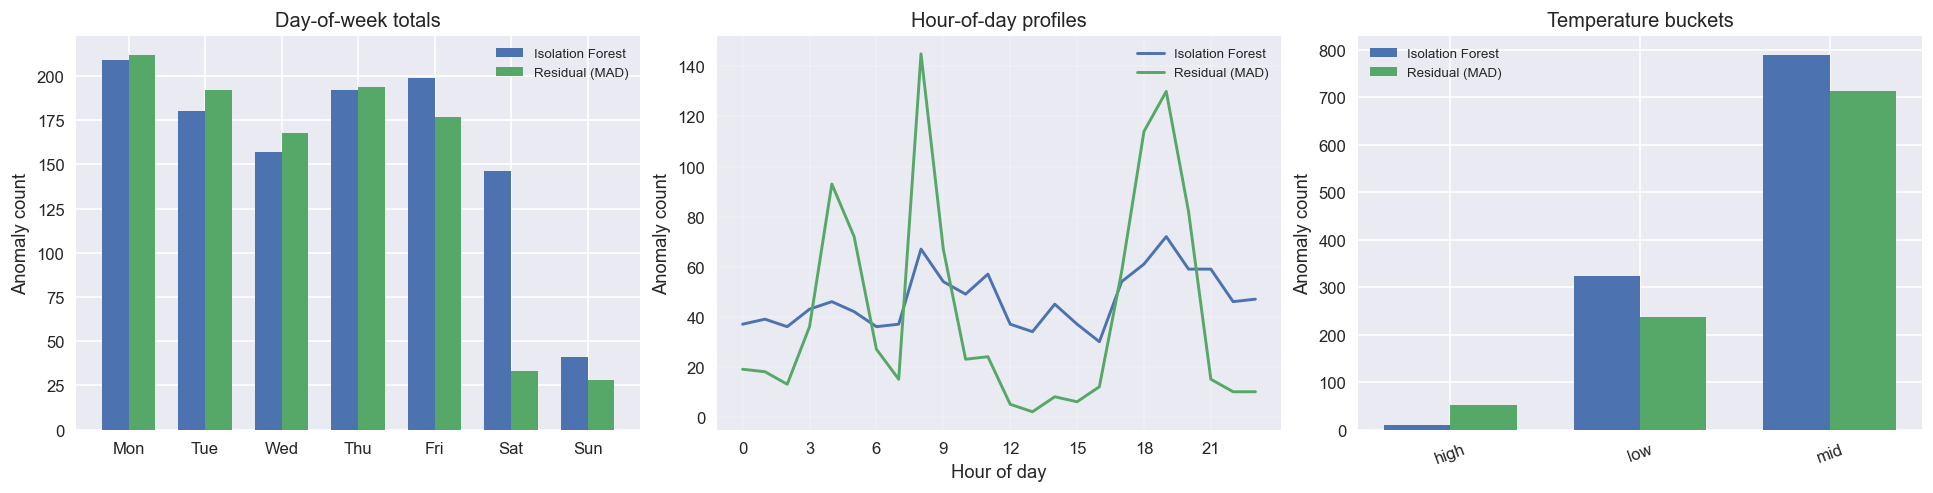

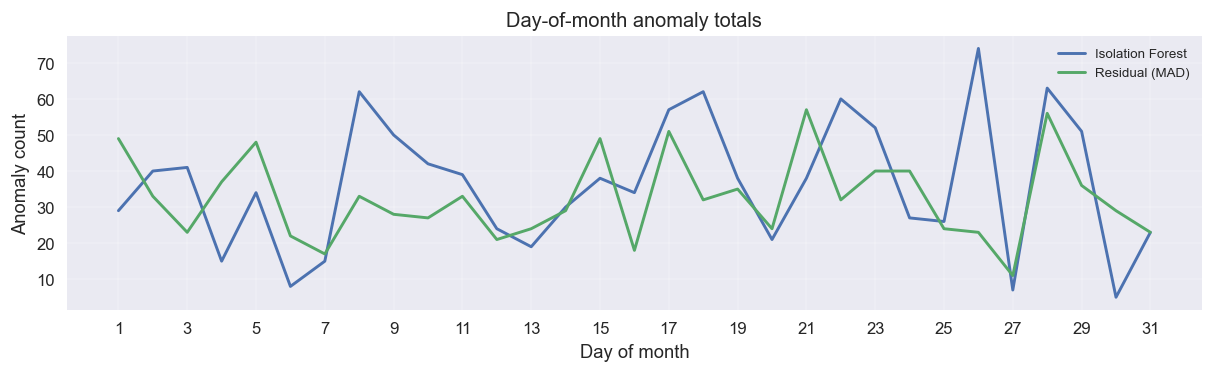

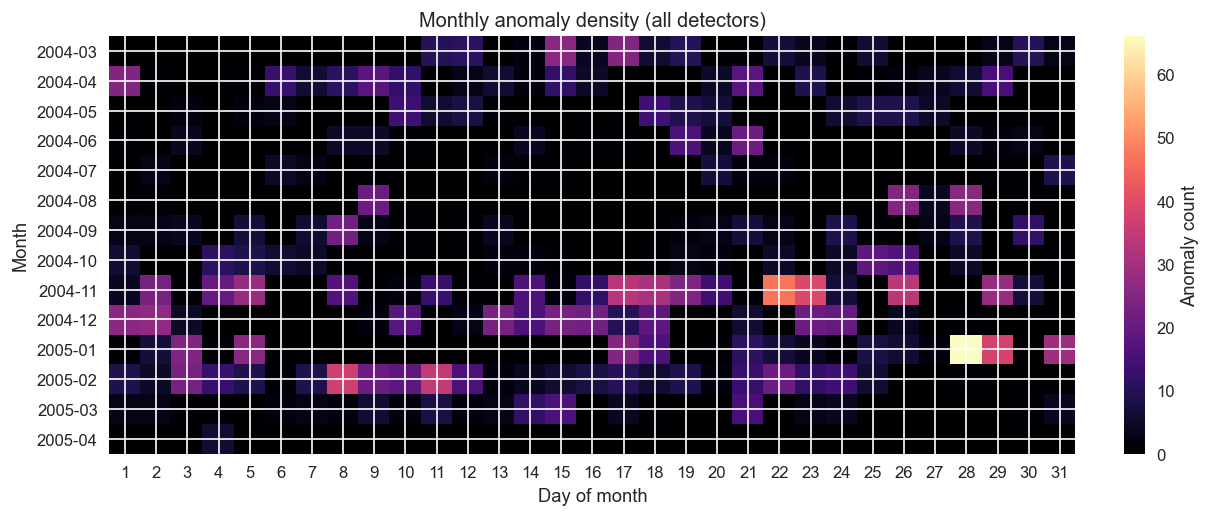

,detector,context,category,count
0,Isolation Forest,weekend,Weekday,937
1,Isolation Forest,weekend,Weekend,187
2,Residual (MAD),weekend,Weekday,943
3,Residual (MAD),weekend,Weekend,61
4,Isolation Forest,hour_of_day,0,37


In [12]:
combined_anoms = pd.concat([residual_anoms, iso_anoms], ignore_index=True)
context_summary = pd.DataFrame(columns=['detector', 'context', 'category', 'count'])

if combined_anoms.empty:
    print('No anomalies available for context comparisons.')
else:
    combined_anoms['weekend_label'] = np.where(combined_anoms['is_weekend'], 'Weekend', 'Weekday')
    combined_anoms['temp_label'] = combined_anoms['temp_bucket'].astype('string').fillna('nan')
    combined_anoms['dom'] = combined_anoms['timestamp'].dt.day
    combined_anoms['month_label'] = combined_anoms['timestamp'].dt.to_period('M').astype(str)

    weekend_counts = (
        combined_anoms.groupby(['detector', 'weekend_label'])
        .size()
        .unstack(fill_value=0)
    )

    hour_profile = (
        combined_anoms.groupby(['detector', 'hour'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=range(24), fill_value=0)
    )

    temp_counts = (
        combined_anoms.groupby(['detector', 'temp_label'])
        .size()
        .unstack(fill_value=0)
    )

    dow_counts = (
        combined_anoms.groupby(['detector', 'dayofweek'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=range(7), fill_value=0)
        .fillna(0)
    )

    dom_counts = (
        combined_anoms.groupby(['detector', 'dom'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=range(1, 32), fill_value=0)
        .fillna(0)
    )

    month_dom = (
        combined_anoms.groupby(['month_label', 'dom'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=range(1, 32), fill_value=0)
        .sort_index()
    )

    context_records = []
    for detector, counts in weekend_counts.iterrows():
        for label, value in counts.items():
            context_records.append({'detector': detector, 'context': 'weekend', 'category': label, 'count': int(value)})
    for detector, counts in hour_profile.iterrows():
        for hour, value in counts.items():
            context_records.append({'detector': detector, 'context': 'hour_of_day', 'category': str(hour), 'count': int(value)})
    for detector, counts in temp_counts.iterrows():
        for label, value in counts.items():
            context_records.append({'detector': detector, 'context': 'temp_bucket', 'category': label, 'count': int(value)})
    for detector, counts in dow_counts.iterrows():
        for dow, value in counts.items():
            context_records.append({'detector': detector, 'context': 'day_of_week', 'category': str(dow), 'count': int(value)})
    for detector, counts in dom_counts.iterrows():
        for dom, value in counts.items():
            context_records.append({'detector': detector, 'context': 'day_of_month', 'category': str(dom), 'count': int(value)})
    context_summary = pd.DataFrame(context_records)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

    width = 0.35
    dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    x = np.arange(len(dow_labels))
    for idx, detector in enumerate(dow_counts.index):
        axes[0].bar(x + idx * width, dow_counts.loc[detector], width=width, label=detector)
    axes[0].set_xticks(x + width / 2)
    axes[0].set_xticklabels(dow_labels)
    axes[0].set_ylabel('Anomaly count')
    axes[0].set_title('Day-of-week totals')
    axes[0].legend(fontsize=8)

    for detector in hour_profile.index:
        axes[1].plot(hour_profile.columns, hour_profile.loc[detector], label=detector)
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_xlabel('Hour of day')
    axes[1].set_ylabel('Anomaly count')
    axes[1].set_title('Hour-of-day profiles')
    axes[1].grid(alpha=0.2)
    axes[1].legend(fontsize=8)

    x2 = np.arange(len(temp_counts.columns))
    for idx, detector in enumerate(temp_counts.index):
        axes[2].bar(x2 + idx * width, temp_counts.loc[detector], width=width, label=detector)
    axes[2].set_xticks(x2 + width / 2)
    axes[2].set_xticklabels(temp_counts.columns, rotation=20)
    axes[2].set_ylabel('Anomaly count')
    axes[2].set_title('Temperature buckets')
    axes[2].legend(fontsize=8)

    if SAVE_FIGS:
        fig.savefig(FIG_DIR / 'context_comparisons.png', dpi=150)

    plt.show()

    fig_dom, ax_dom = plt.subplots(figsize=(10, 3), constrained_layout=True)
    days = np.arange(1, 32)
    for detector in dom_counts.index:
        ax_dom.plot(days, dom_counts.loc[detector], label=detector)
    ax_dom.set_xticks(range(1, 32, 2))
    ax_dom.set_xlabel('Day of month')
    ax_dom.set_ylabel('Anomaly count')
    ax_dom.set_title('Day-of-month anomaly totals')
    ax_dom.grid(alpha=0.2)
    ax_dom.legend(fontsize=8)
    if SAVE_FIGS:
        fig_dom.savefig(FIG_DIR / 'day_of_month_totals.png', dpi=150)
    plt.show()

    fig_heat, ax_heat = plt.subplots(figsize=(10, max(2, 0.3 * len(month_dom))), constrained_layout=True)
    im = ax_heat.imshow(month_dom.values, aspect='auto', cmap='magma')
    ax_heat.set_xticks(range(month_dom.shape[1]))
    ax_heat.set_xticklabels(month_dom.columns)
    ax_heat.set_yticks(range(month_dom.shape[0]))
    ax_heat.set_yticklabels(month_dom.index)
    ax_heat.set_xlabel('Day of month')
    ax_heat.set_ylabel('Month')
    ax_heat.set_title('Monthly anomaly density (all detectors)')
    fig_heat.colorbar(im, ax=ax_heat, label='Anomaly count')
    if SAVE_FIGS:
        fig_heat.savefig(FIG_DIR / 'day_of_month_heatmap.png', dpi=150)
    plt.show()

context_summary.head()


Visualize a 2004 window with detector hits.

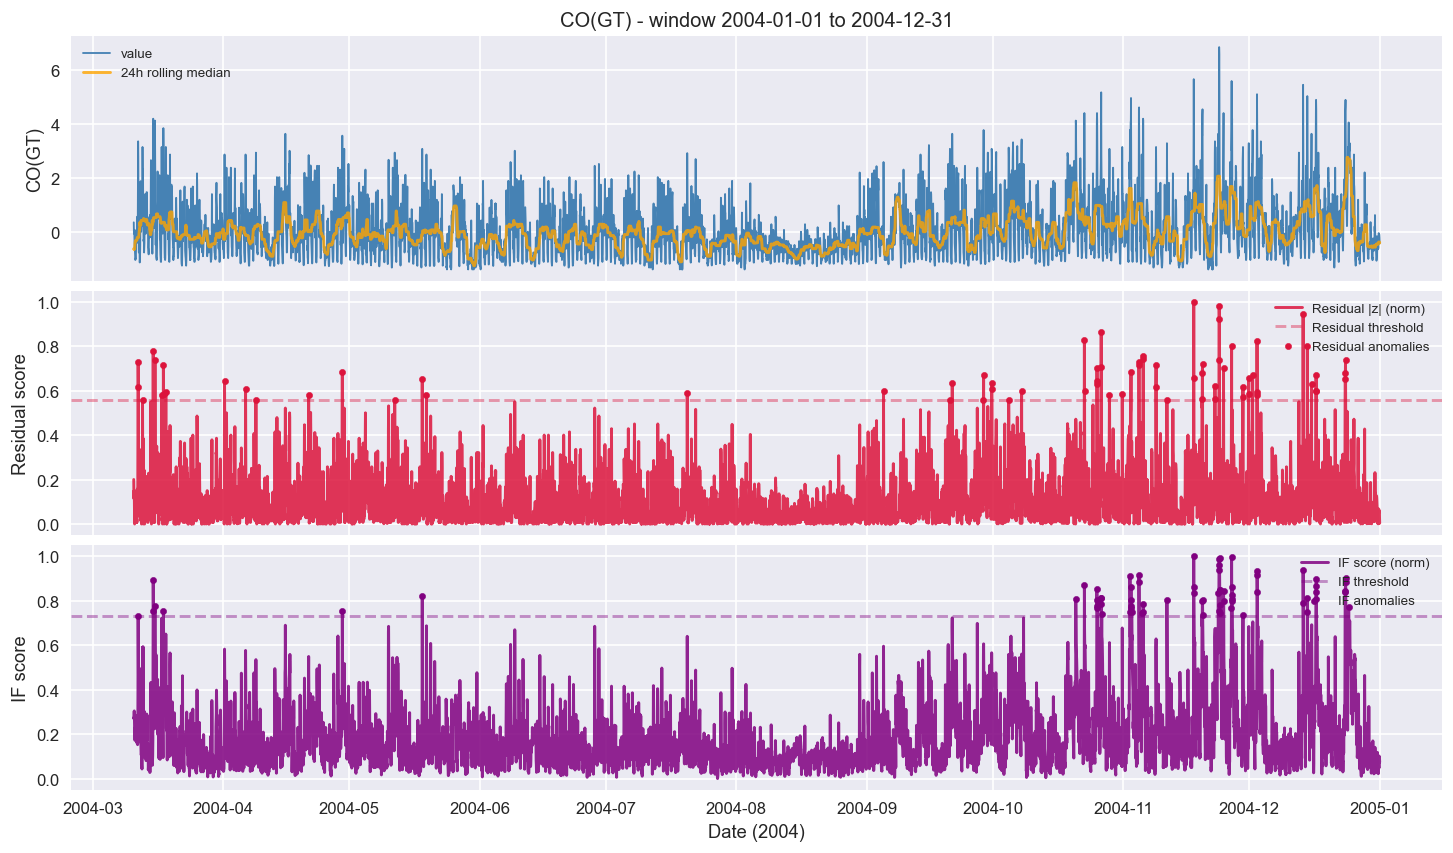

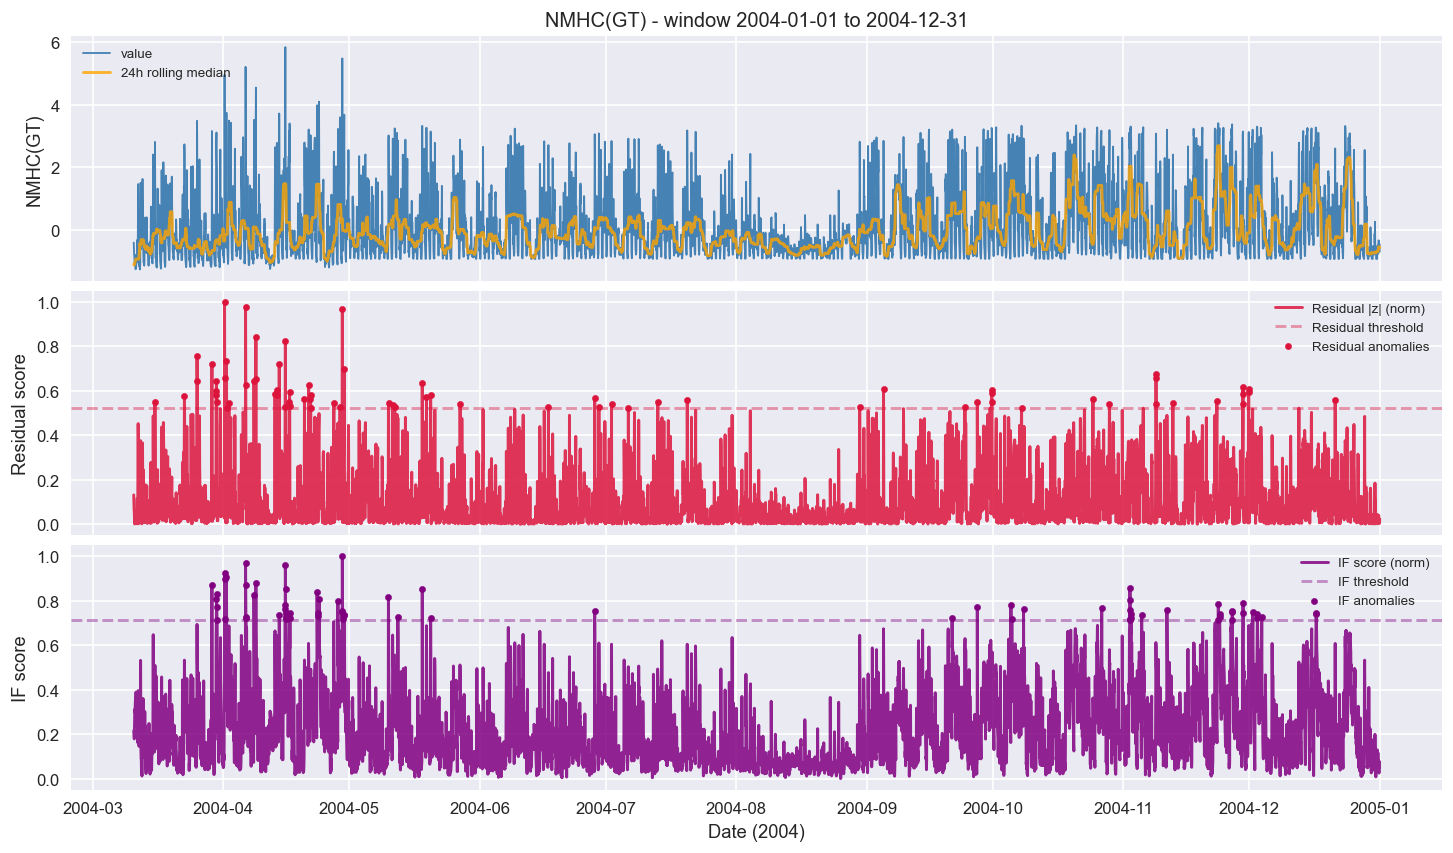

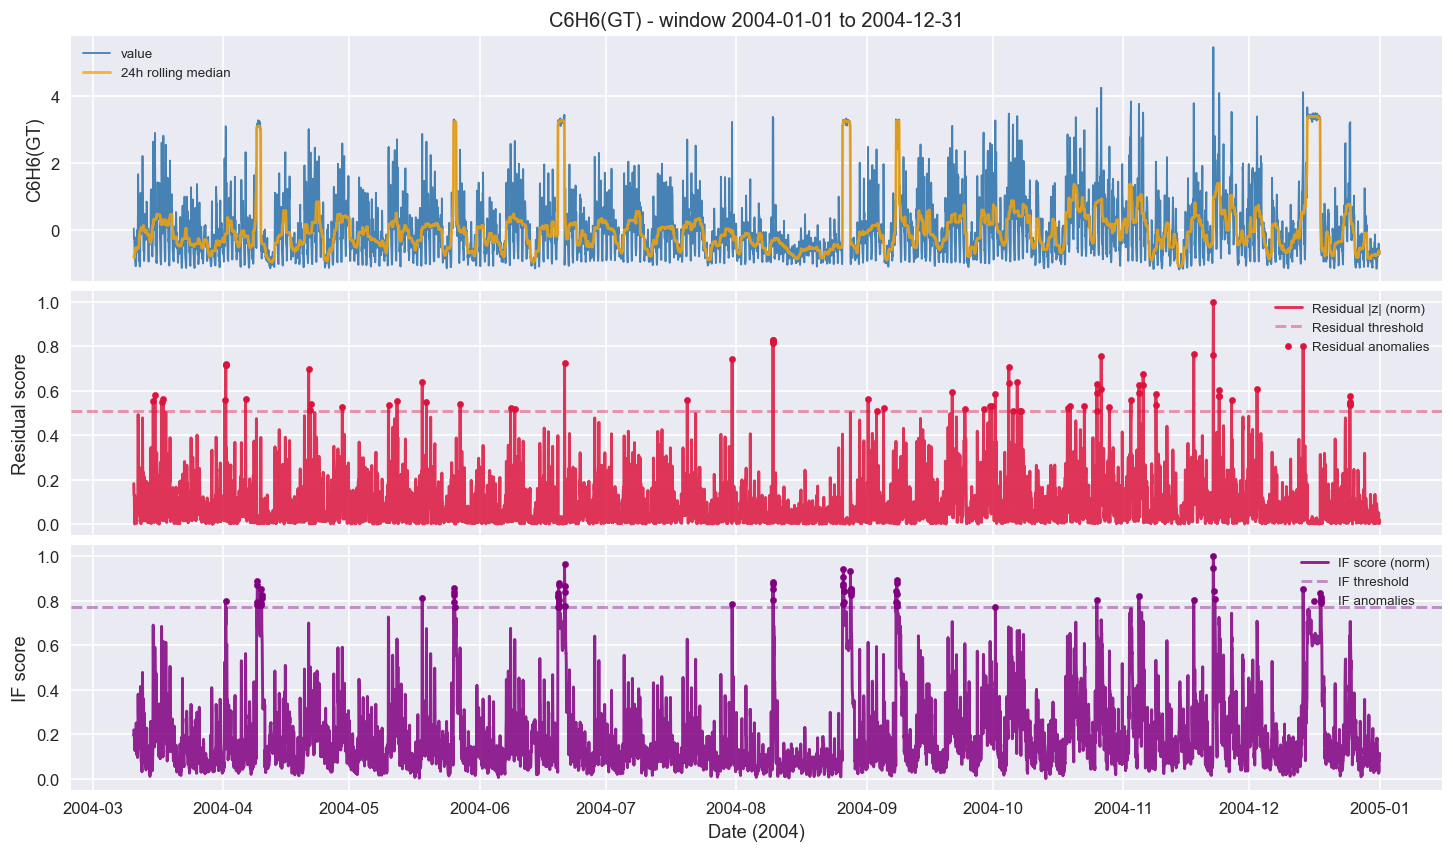

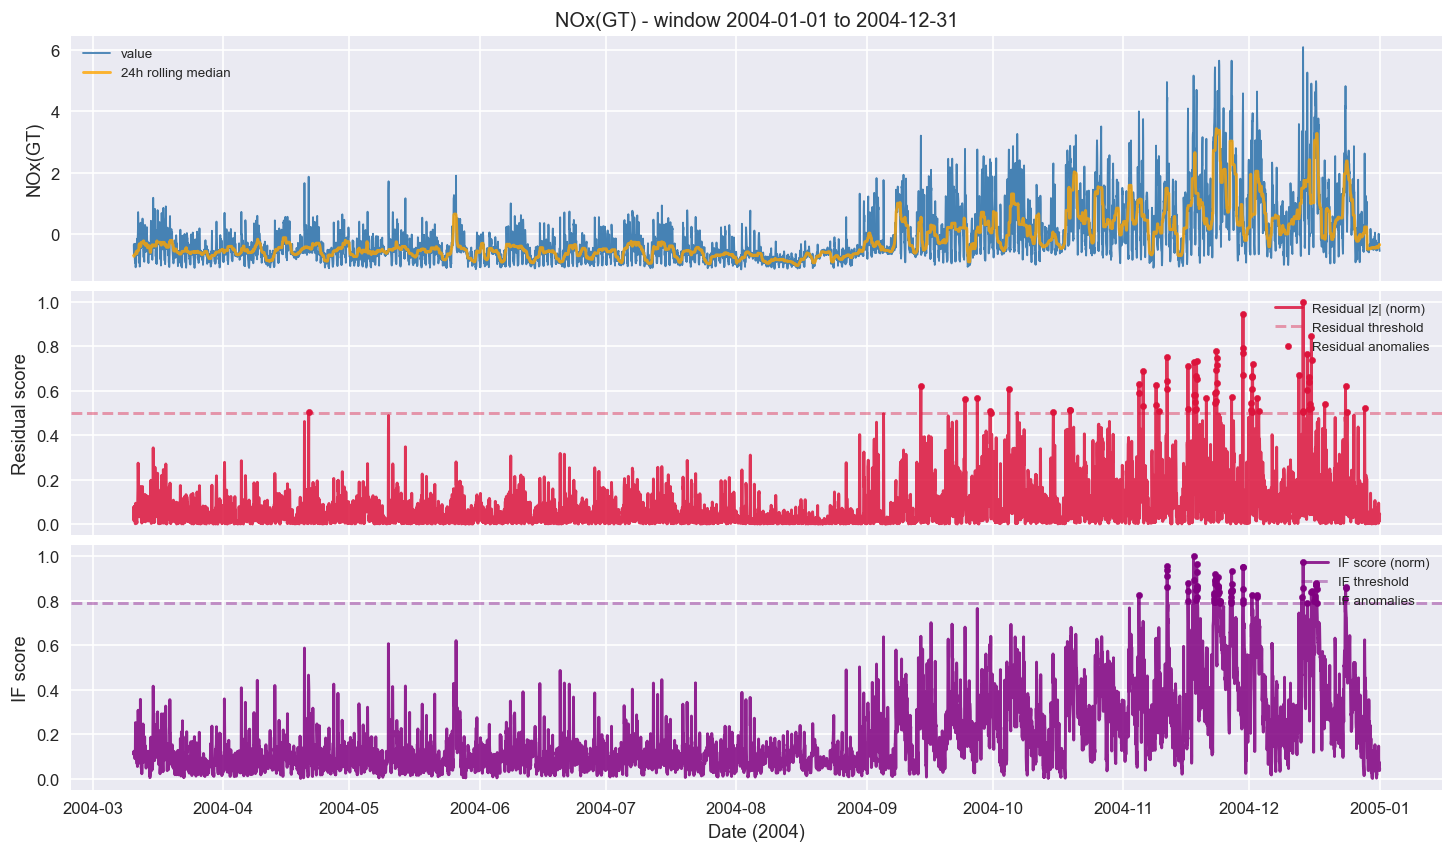

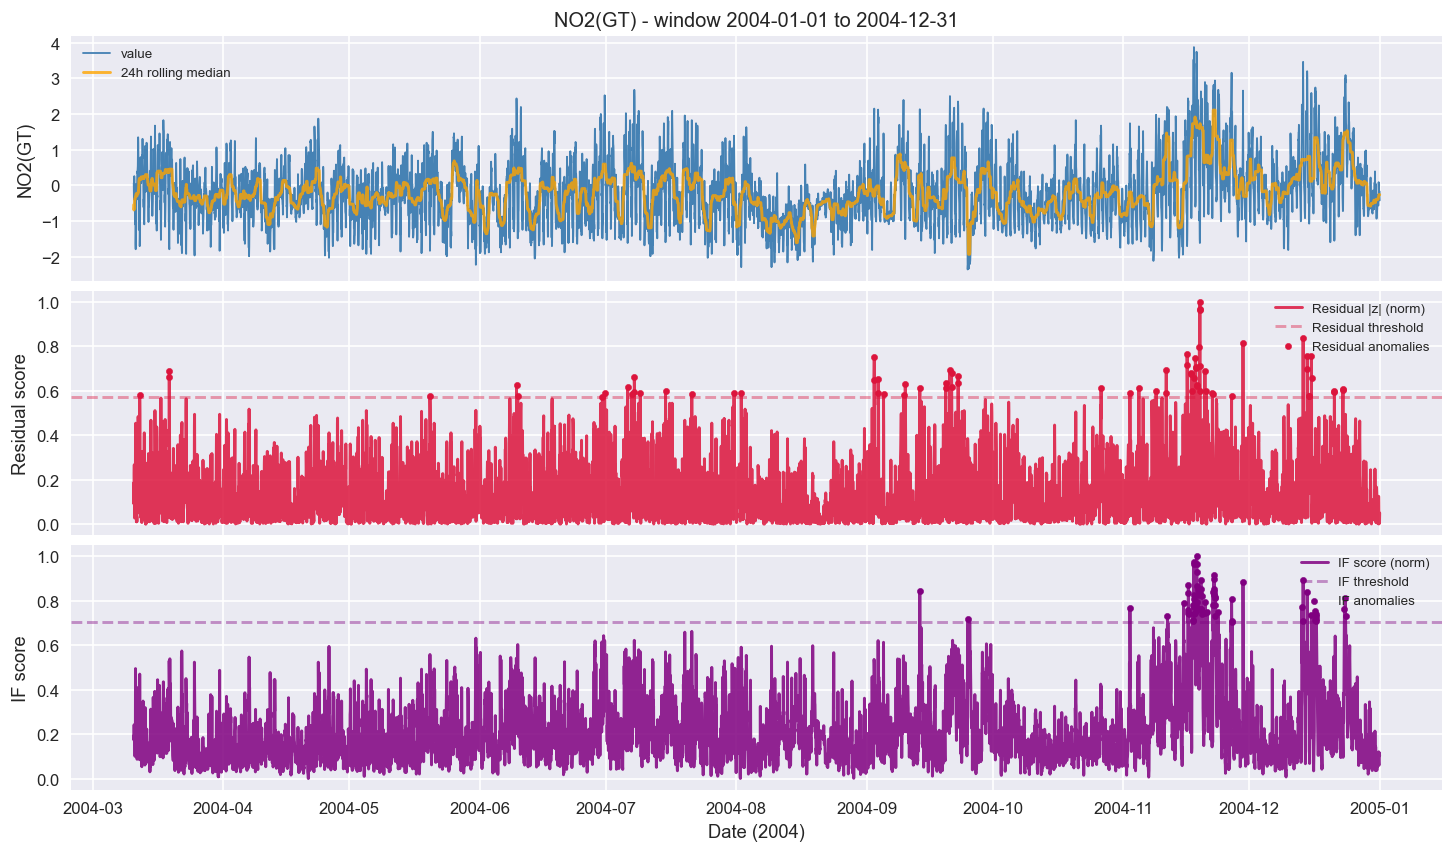

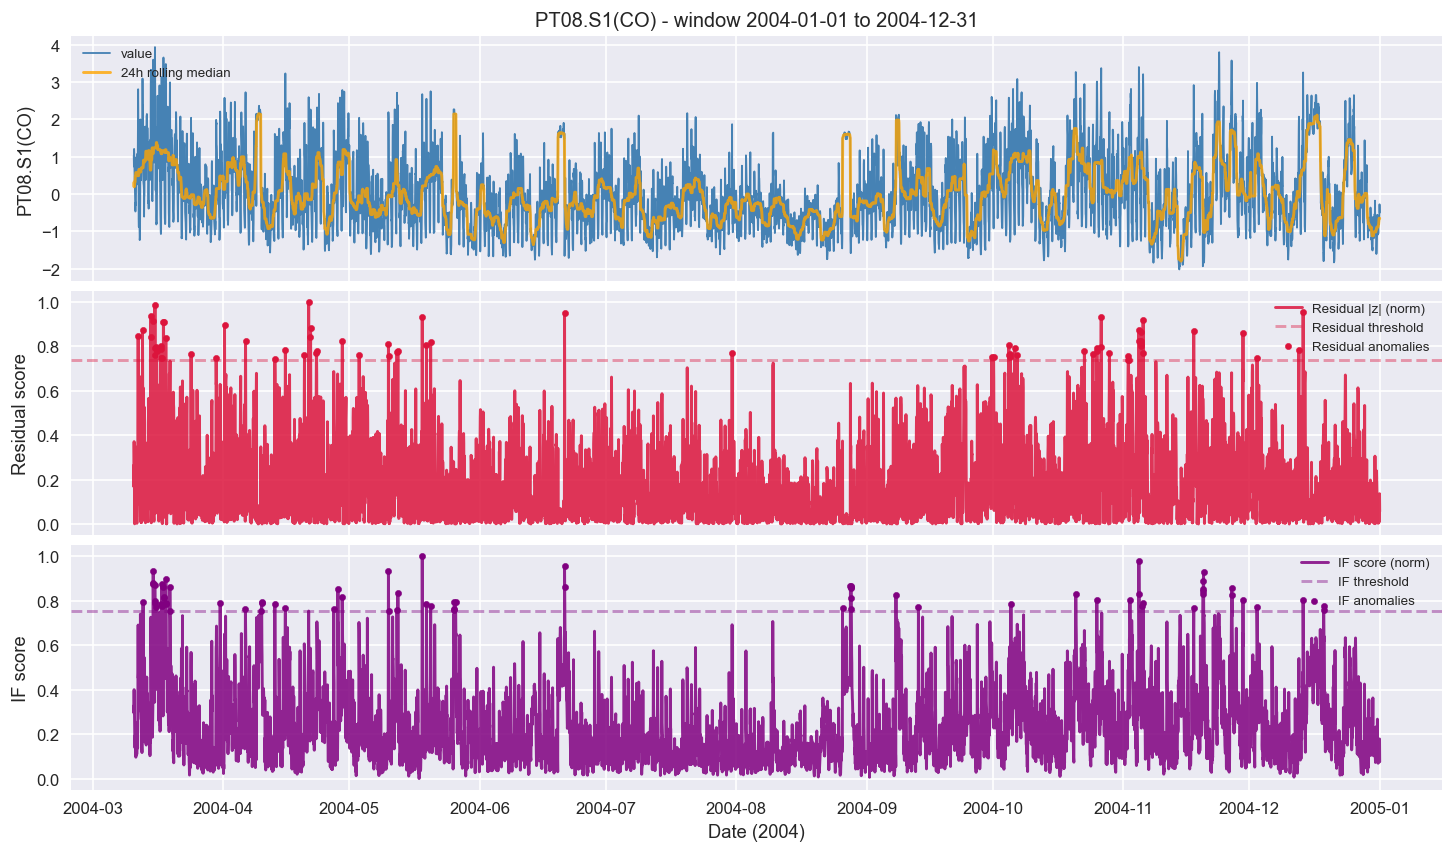

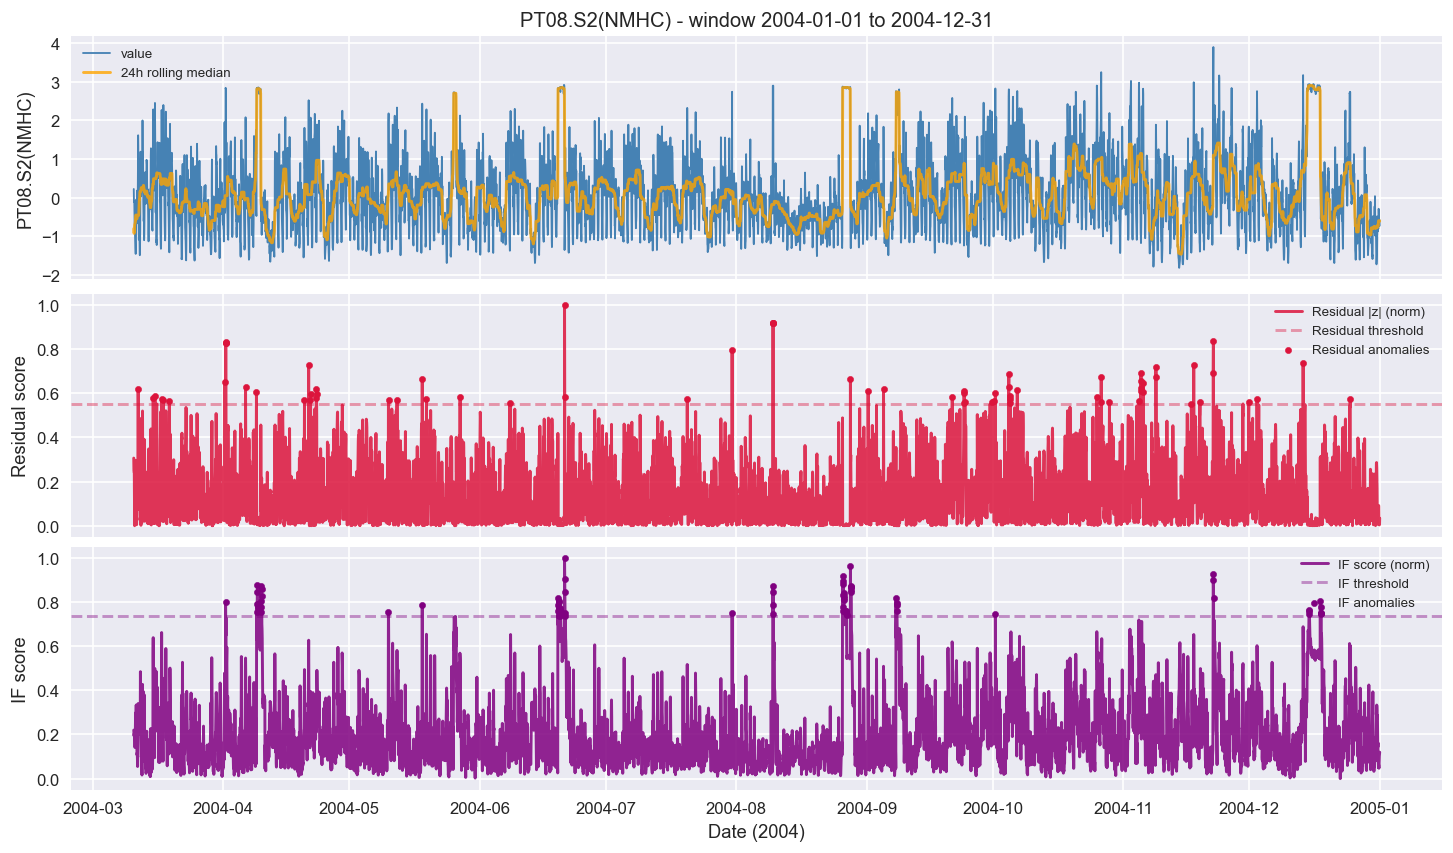

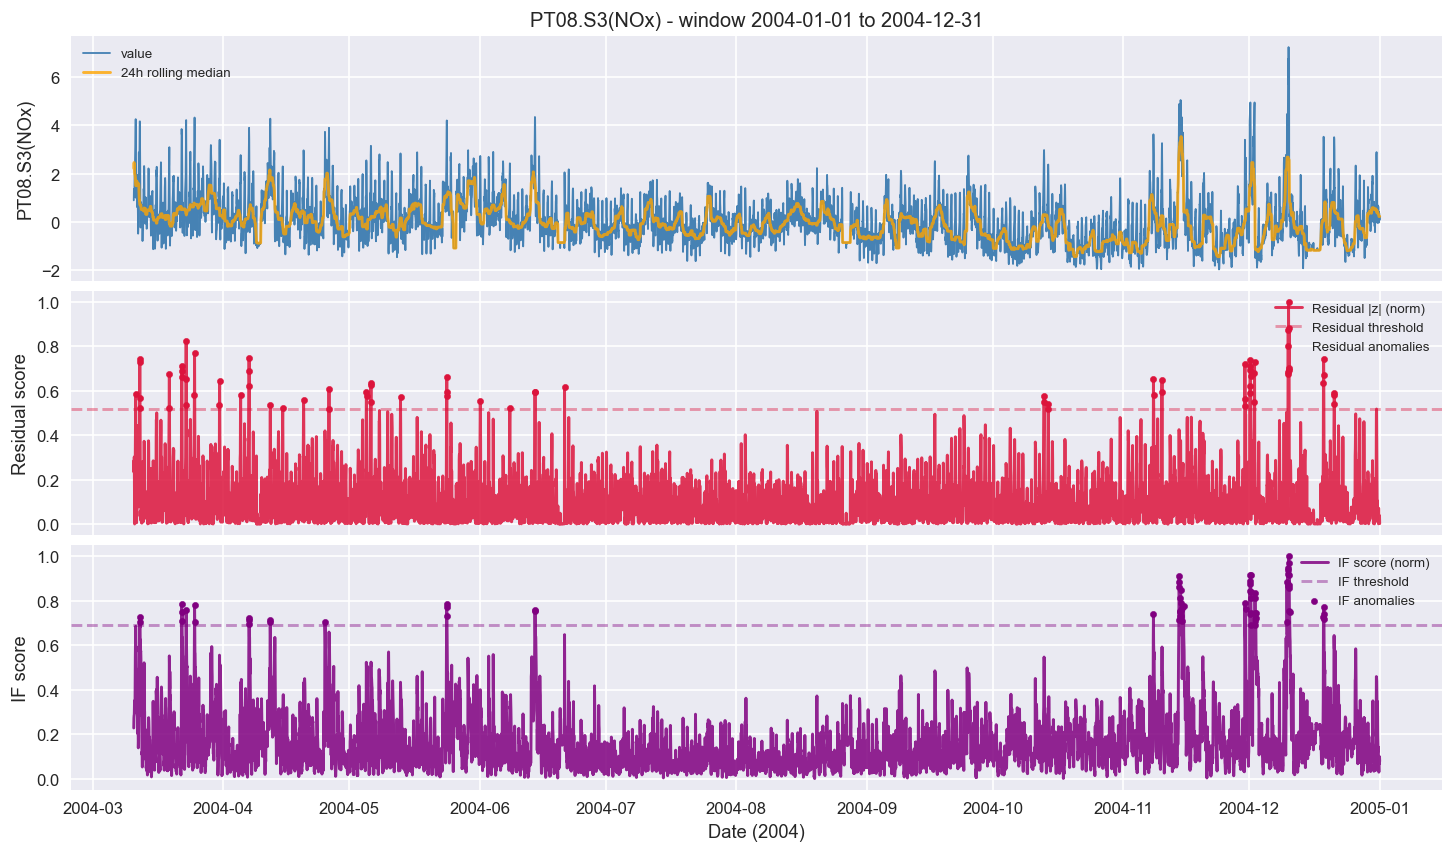

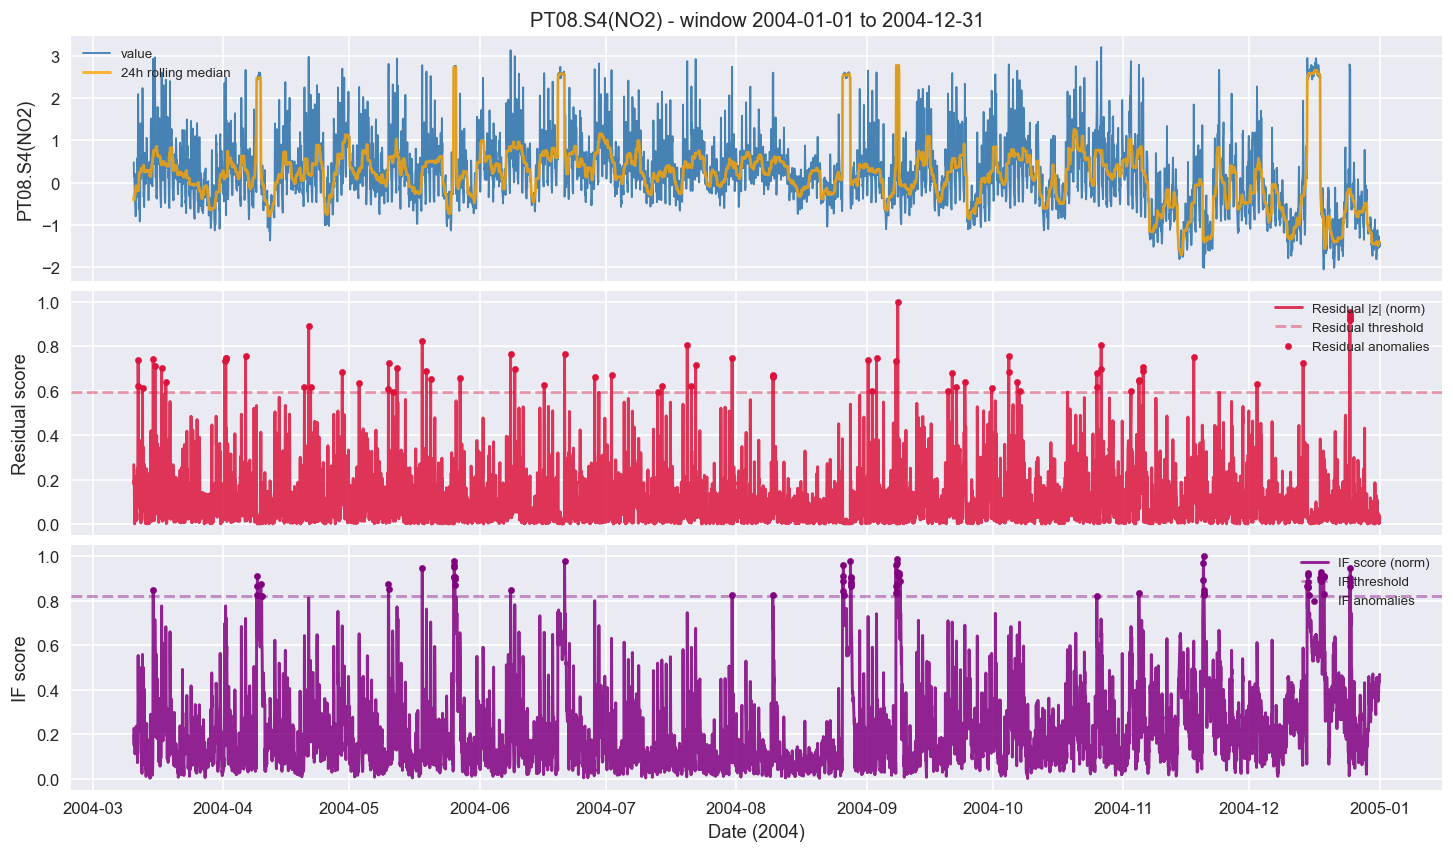

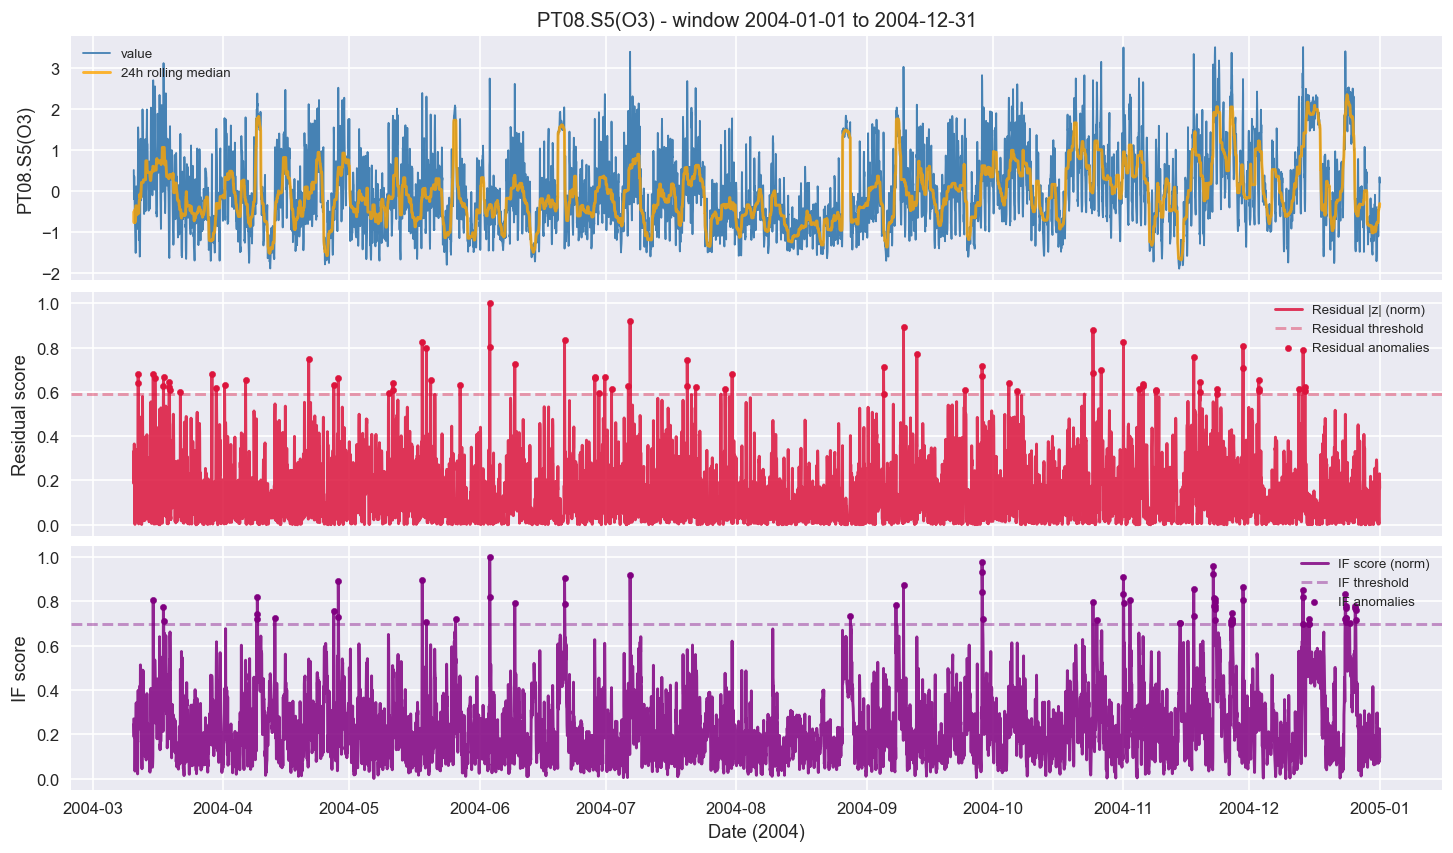

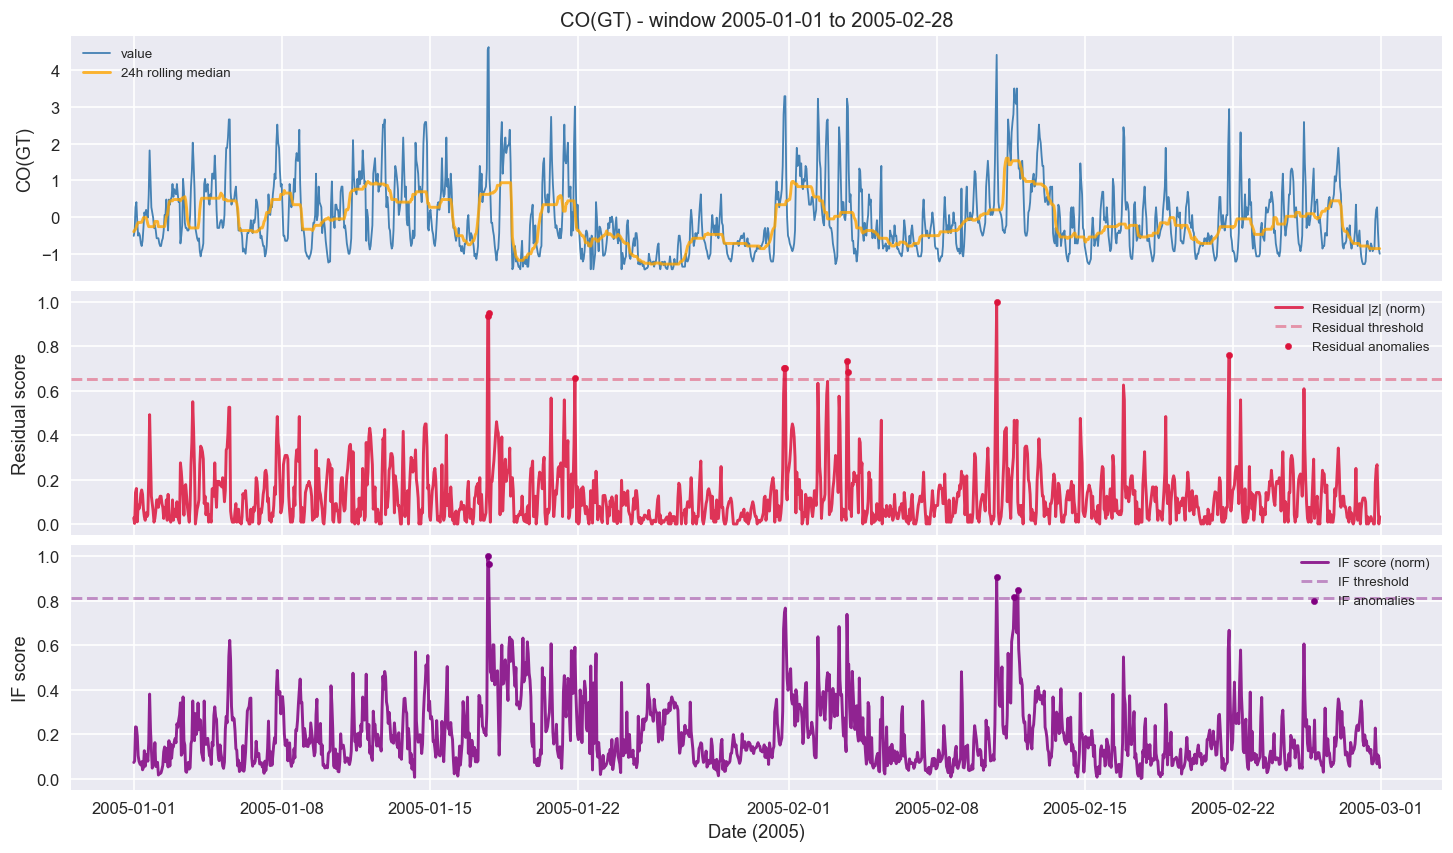

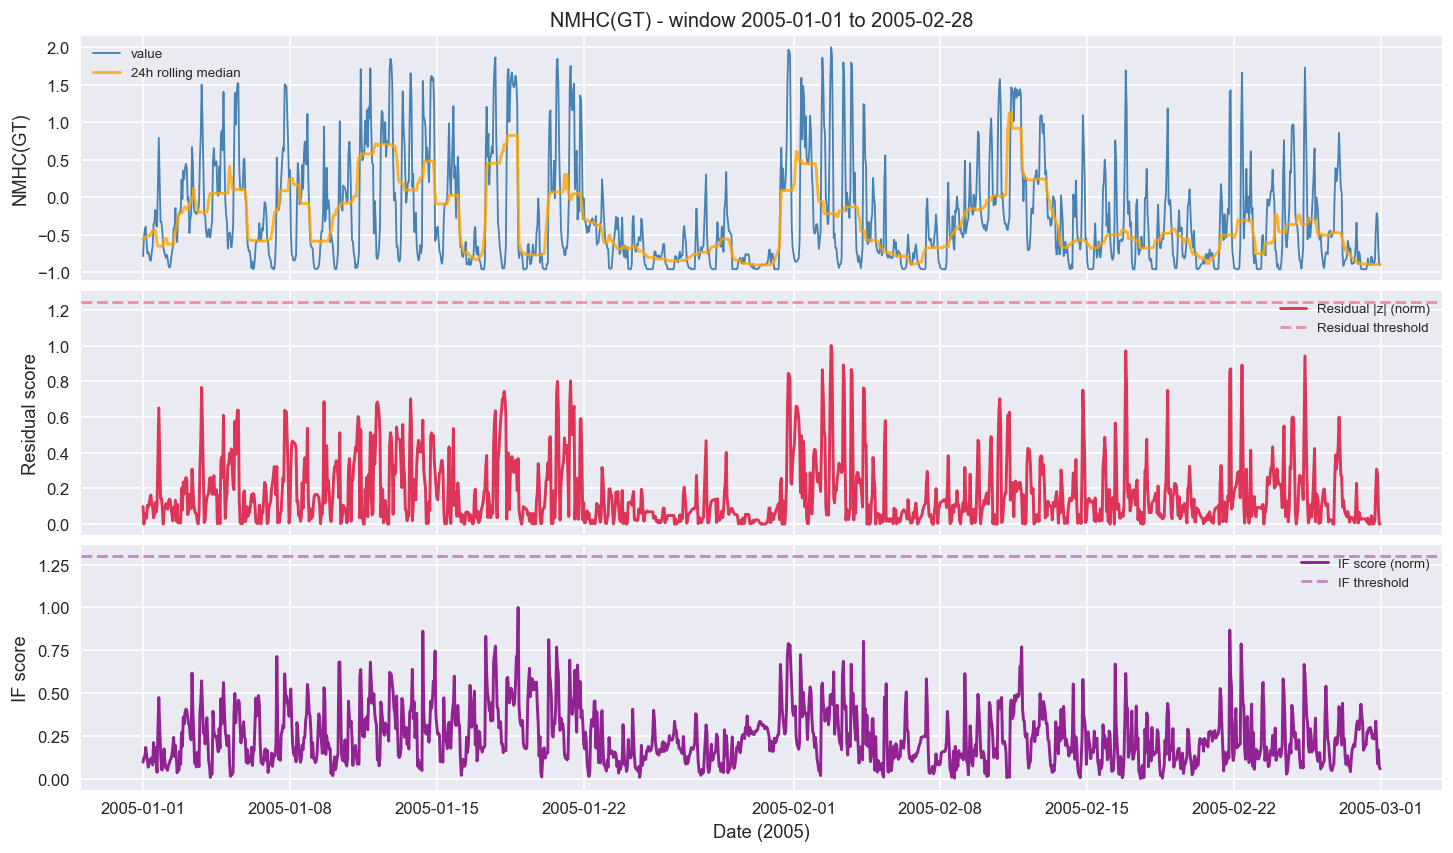

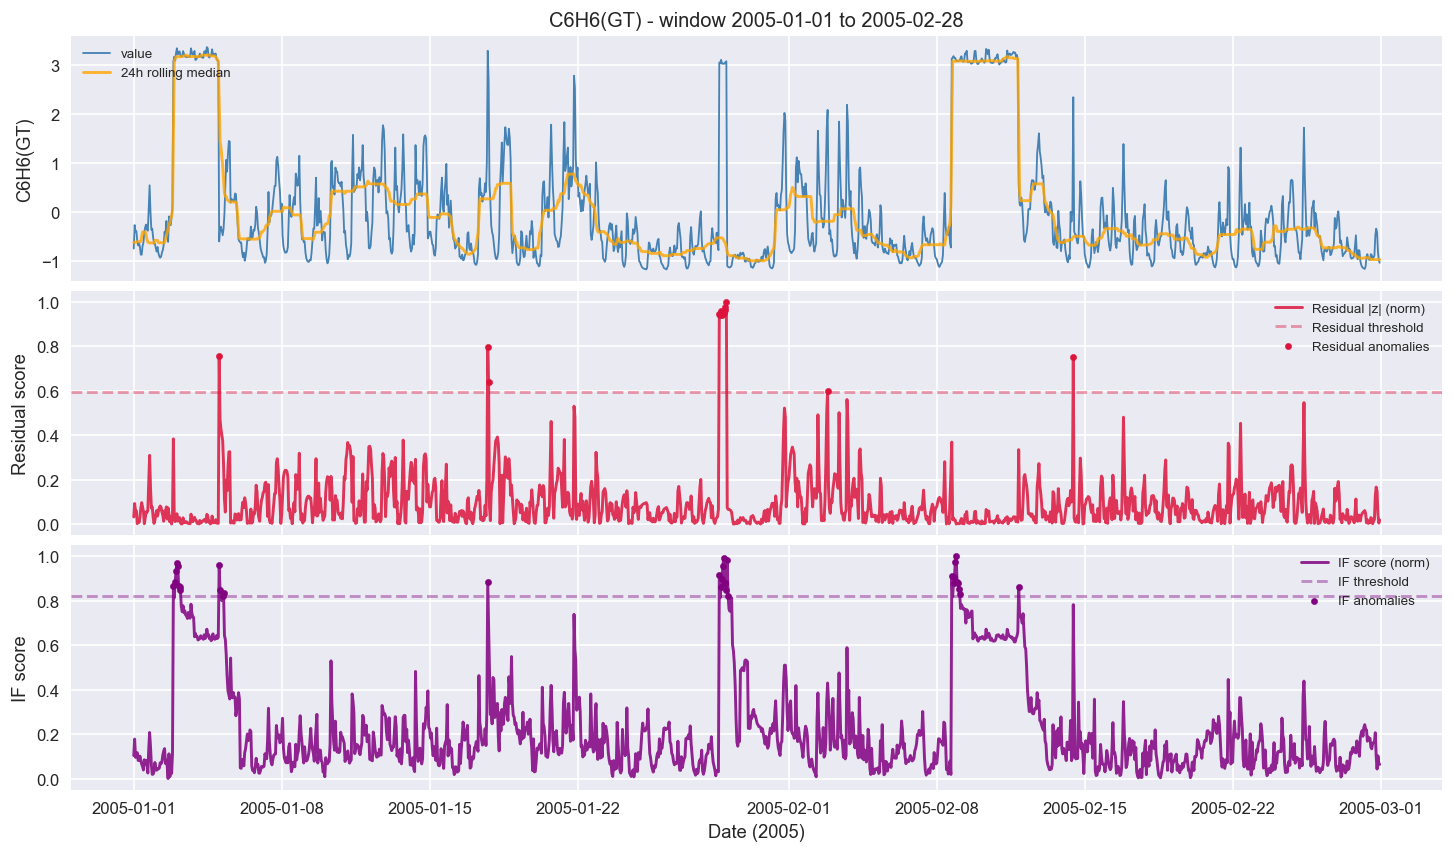

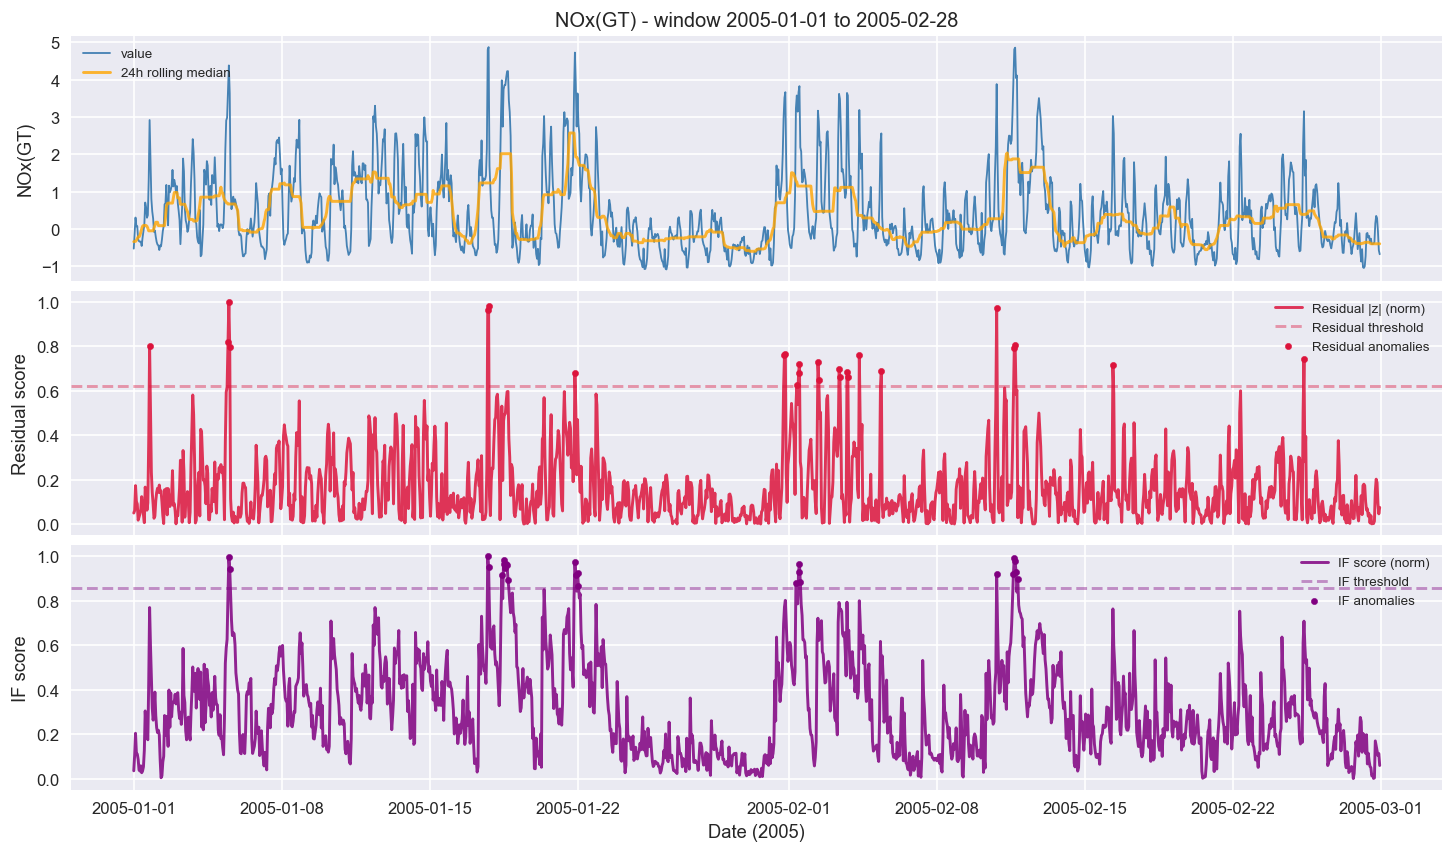

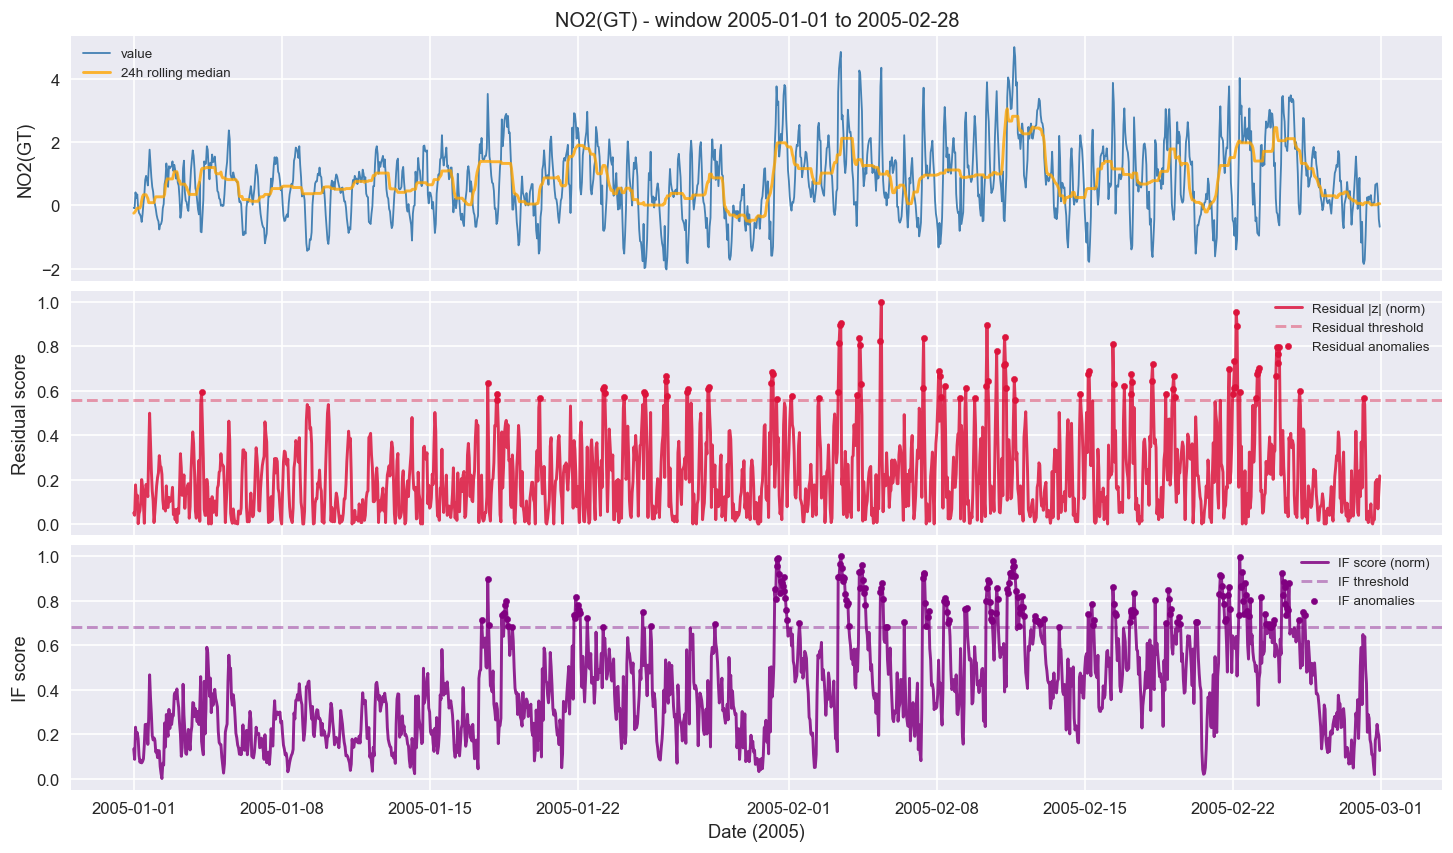

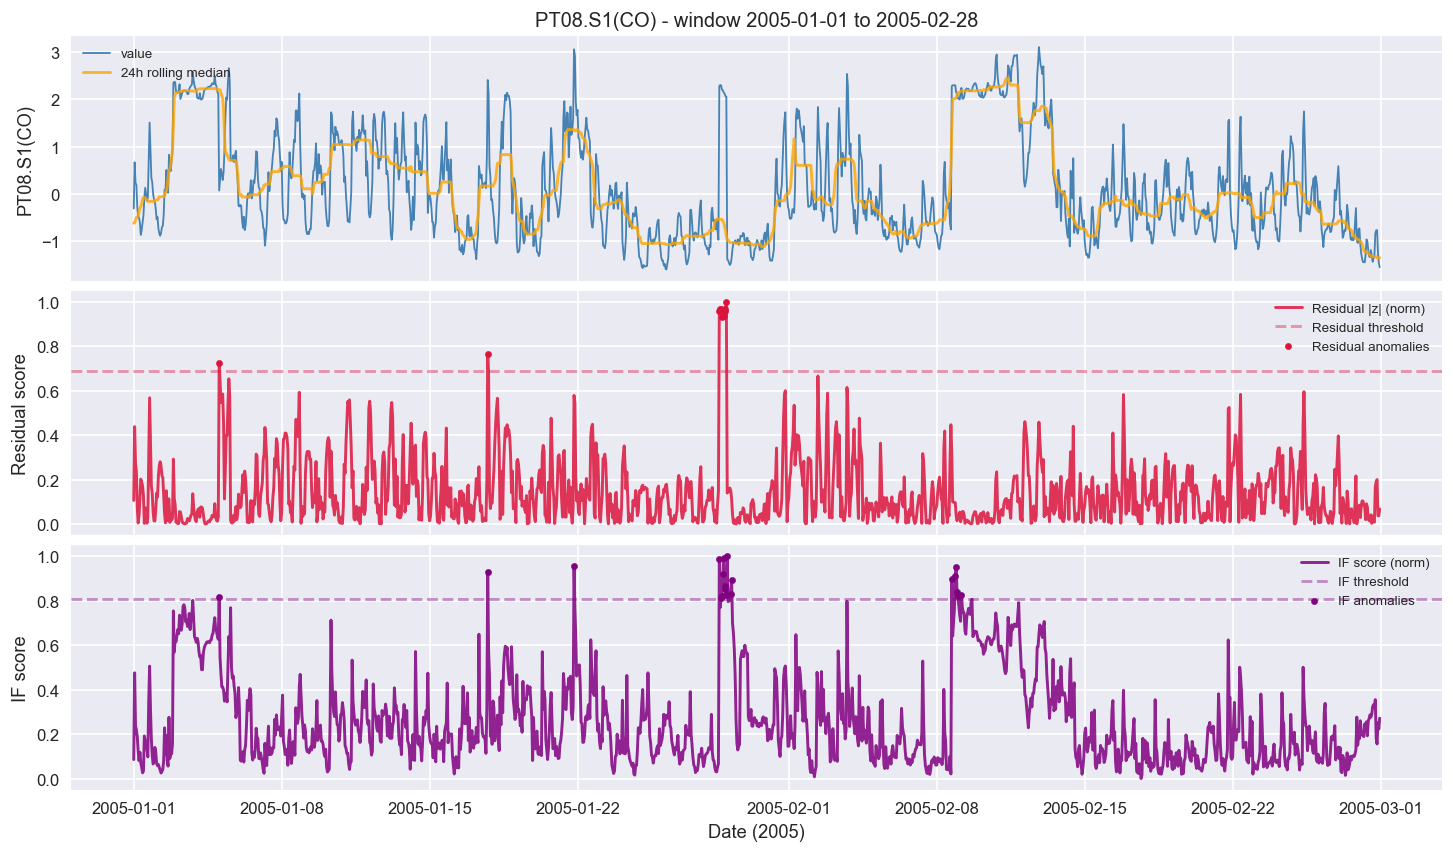

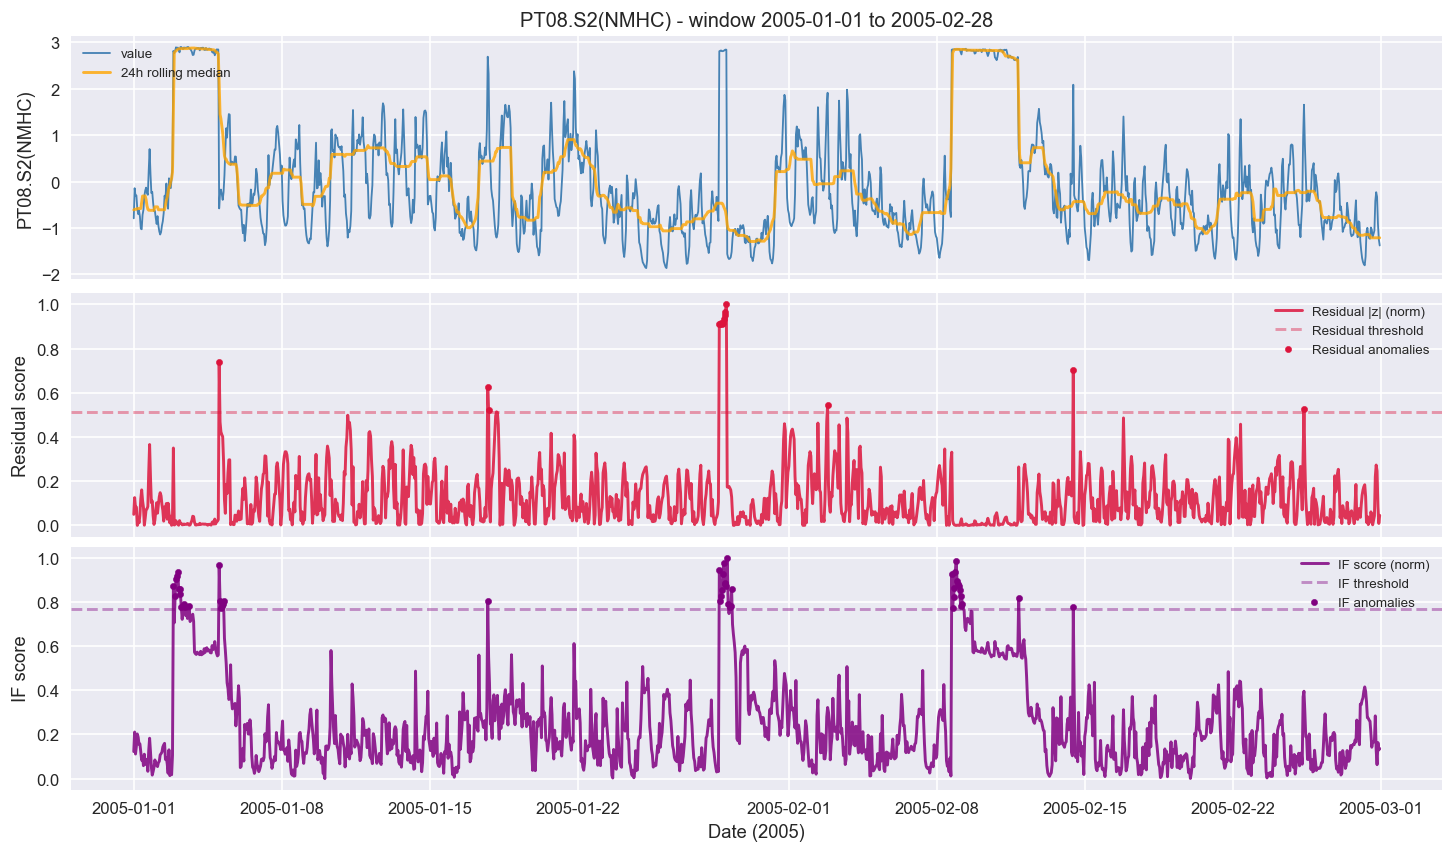

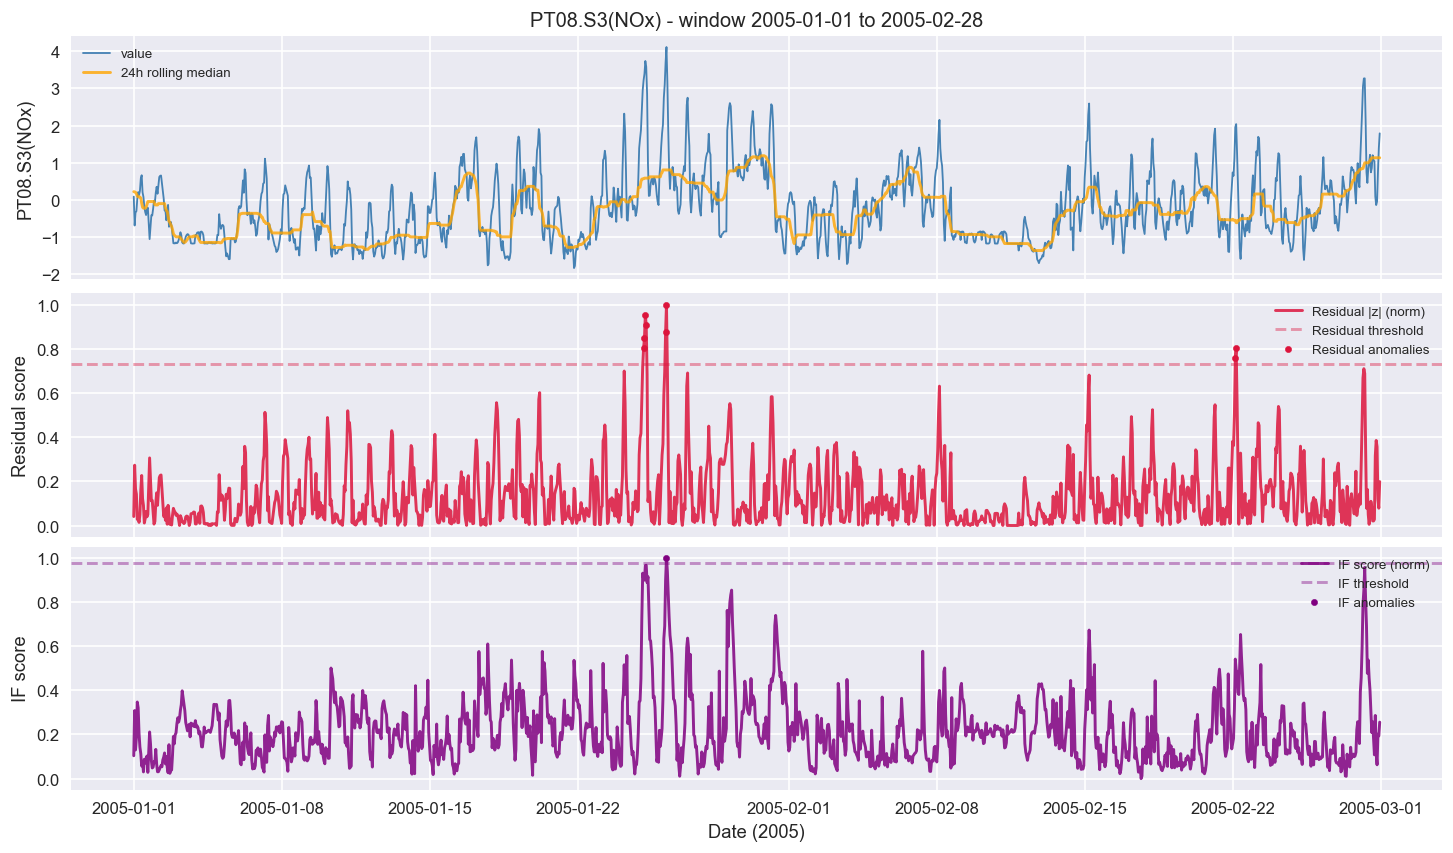

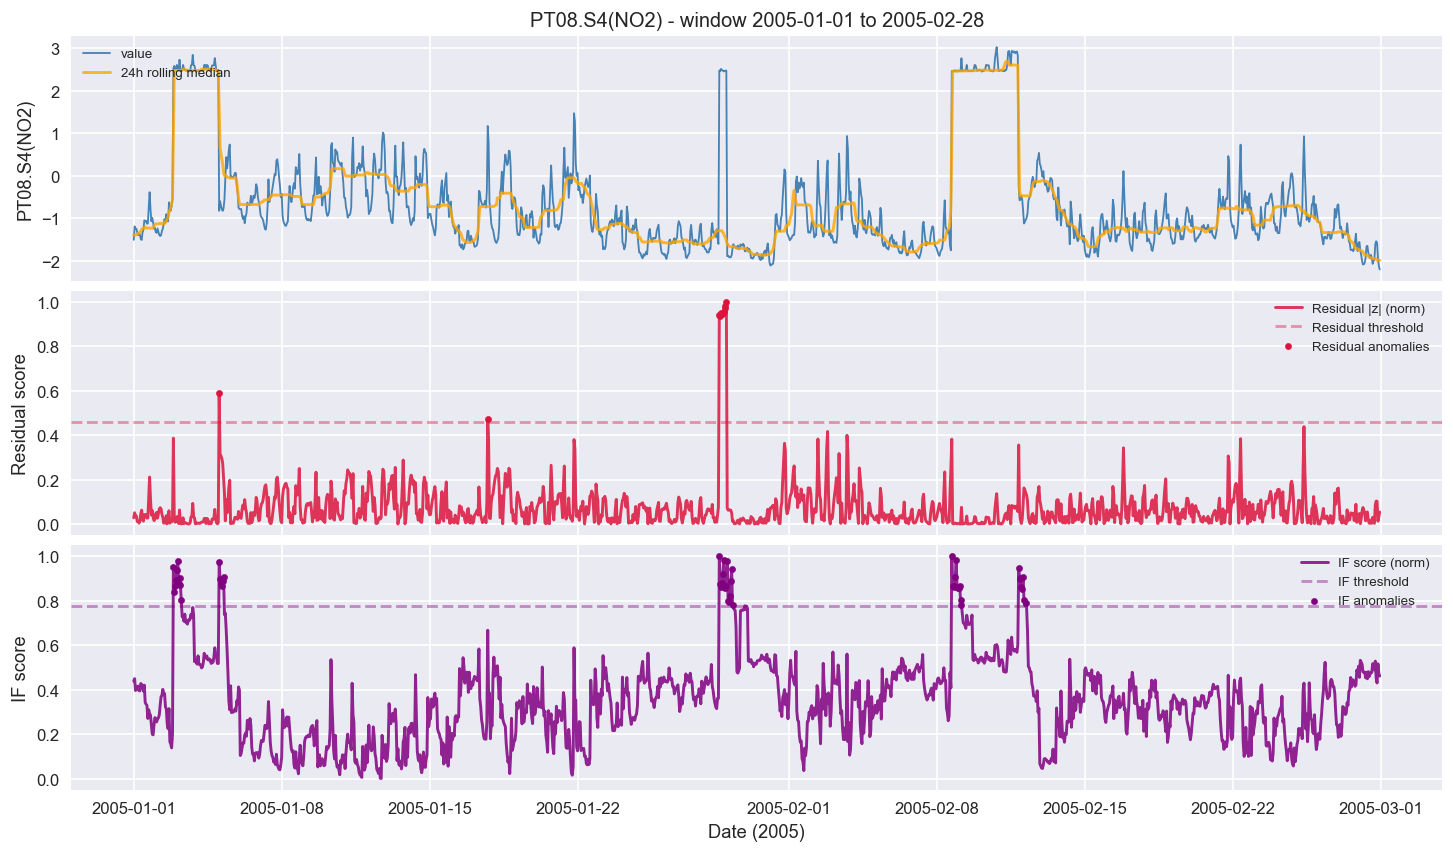

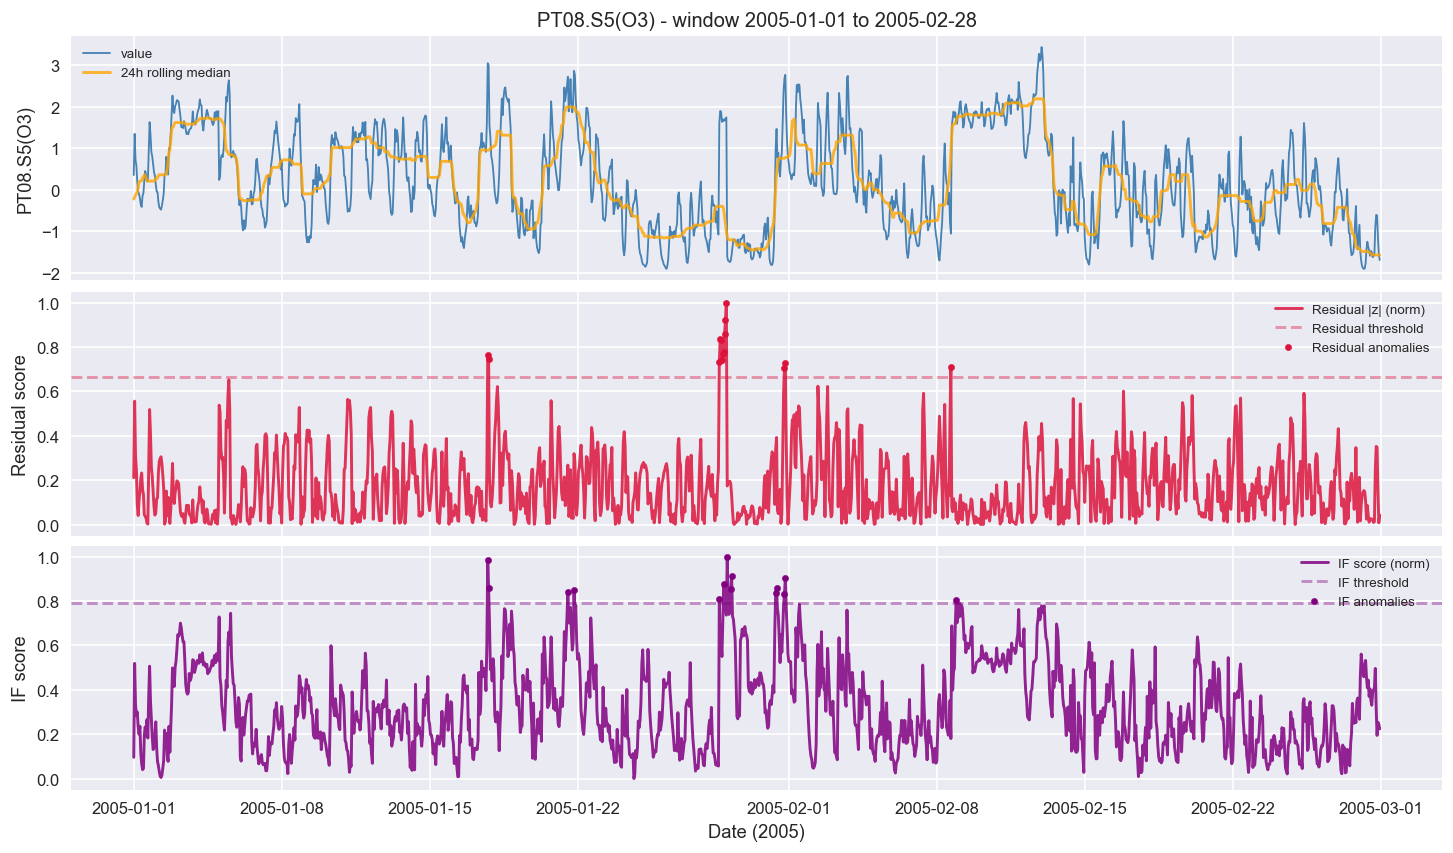

In [13]:
windows = [
    (pd.Timestamp('2004-01-01'), pd.Timestamp('2004-12-31 23:00:00')),
    (pd.Timestamp('2005-01-01'), pd.Timestamp('2005-02-28 23:00:00')),
]

for plot_start, plot_end in windows:
    plot_slice = slice(plot_start, plot_end)

    def normalize_threshold(value, min_val, max_val):
        if not np.isfinite(value) or not np.isfinite(min_val) or not np.isfinite(max_val):
            return np.nan
        span = max_val - min_val
        if span <= 0:
            return np.nan
        return (value - min_val) / span

    for stream in ALL_STREAMS:
        res_stream = residual_scores[residual_scores['stream'] == stream].set_index('timestamp')
        iso_stream = iso_scores[iso_scores['stream'] == stream].set_index('timestamp')
        values = df.loc[plot_slice, stream]
        if values.dropna().empty:
            print(f"{stream}: missing values in window {plot_start.date()} to {plot_end.date()}, skipping.")
            continue

        res_slice = res_stream.loc[plot_slice]
        iso_slice = iso_stream.loc[plot_slice]
        if res_slice.empty or iso_slice.empty:
            print(f"{stream}: detector scores missing in window {plot_start.date()} to {plot_end.date()}.")
            continue

        res_norm, res_min, res_max = normalize_series(res_slice['score'])
        iso_norm, iso_min, iso_max = normalize_series(iso_slice['score'])
        res_thr_norm = normalize_threshold(
            res_slice['threshold'].dropna().iloc[0] if not res_slice['threshold'].dropna().empty else np.nan,
            res_min,
            res_max,
        )
        iso_thr_norm = normalize_threshold(
            iso_slice['threshold'].dropna().iloc[0] if not iso_slice['threshold'].dropna().empty else np.nan,
            iso_min,
            iso_max,
        )

        fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

        axes[0].plot(values.index, values.values, label='value', color='steelblue', linewidth=1.1)
        axes[0].plot(res_slice.index, res_slice['baseline'], label='24h rolling median', color='orange', alpha=0.8)
        axes[0].set_ylabel(stream)
        axes[0].set_title(f"{stream} - window {plot_start.date()} to {plot_end.date()}")
        axes[0].legend(loc='upper left', fontsize=8)

        res_hits = residual_anoms[
            (residual_anoms['stream'] == stream)
            & (residual_anoms['timestamp'].between(plot_start, plot_end))
        ]
        iso_hits = iso_anoms[
            (iso_anoms['stream'] == stream)
            & (iso_anoms['timestamp'].between(plot_start, plot_end))
        ]

        axes[1].plot(res_norm.index, res_norm, label='Residual |z| (norm)', color='crimson', alpha=0.85)
        if np.isfinite(res_thr_norm):
            axes[1].axhline(res_thr_norm, color='crimson', linestyle='--', alpha=0.4, label='Residual threshold')
        if not res_hits.empty:
            res_hit_norm = res_norm.reindex(res_hits['timestamp']).to_numpy()
            axes[1].scatter(res_hits['timestamp'], res_hit_norm, color='crimson', s=14, label='Residual anomalies')
        axes[1].set_ylabel('Residual score')
        axes[1].legend(loc='upper right', fontsize=8)

        axes[2].plot(iso_norm.index, iso_norm, label='IF score (norm)', color='purple', alpha=0.85)
        if np.isfinite(iso_thr_norm):
            axes[2].axhline(iso_thr_norm, color='purple', linestyle='--', alpha=0.4, label='IF threshold')
        if not iso_hits.empty:
            iso_hit_norm = iso_norm.reindex(iso_hits['timestamp']).to_numpy()
            axes[2].scatter(iso_hits['timestamp'], iso_hit_norm, color='purple', s=14, label='IF anomalies')
        axes[2].set_ylabel('IF score')
        axes[2].set_xlabel(f"Date ({plot_start.year})")
        axes[2].legend(loc='upper right', fontsize=8)

        if SAVE_FIGS:
            fig_path = FIG_DIR / f"{safe_stream_name(stream)}_{plot_start.year}_anomalies.png"
            fig.savefig(fig_path, dpi=150)

        plt.show()


Save anomaly tables for downstream analysis.

In [14]:
residual_path = OUT_DIR / 'residual_anomalies.csv'
iso_path = OUT_DIR / 'isolation_forest_anomalies.csv'
summary_path = OUT_DIR / 'detector_summary.csv'
context_summary_path = OUT_DIR / 'context_summary.csv'

residual_anoms.to_csv(residual_path, index=False)
iso_anoms.to_csv(iso_path, index=False)
stream_summary.to_csv(summary_path, index=False)
context_summary.to_csv(context_summary_path, index=False)

print(f"Saved residual anomalies to {residual_path}")
print(f"Saved isolation forest anomalies to {iso_path}")
print(f"Saved summary to {summary_path}")
print(f"Saved context summary to {context_summary_path}")


Saved residual anomalies to artifacts\residual_anomalies.csv
Saved isolation forest anomalies to artifacts\isolation_forest_anomalies.csv
Saved summary to artifacts\detector_summary.csv
Saved context summary to artifacts\context_summary.csv
